In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('wine_data.csv', header=None, usecols=[0, 1, 2])
df

,0,1,2
0,1,14.23,1.71
1,1,13.20,1.78
2,1,13.16,2.36
3,1,14.37,1.95
4,1,13.24,2.59
...,...,...,...
173,3,13.71,5.65
174,3,13.40,3.91
175,3,13.27,4.28
176,3,13.17,2.59


In [5]:
df.columns = ['Class Label', 'Alcohol', 'Malic Acid']
df

,Class Label,Alcohol,Malic Acid
0,1,14.23,1.71
1,1,13.20,1.78
2,1,13.16,2.36
3,1,14.37,1.95
4,1,13.24,2.59
...,...,...,...
173,3,13.71,5.65
174,3,13.40,3.91
175,3,13.27,4.28
176,3,13.17,2.59


<Axes: xlabel='Alcohol', ylabel='Density'>

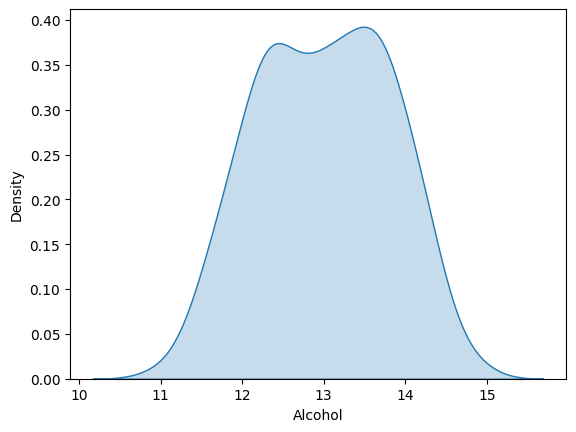

In [10]:
sns.kdeplot(df['Alcohol'], fill=True)

<Axes: xlabel='Malic Acid', ylabel='Density'>

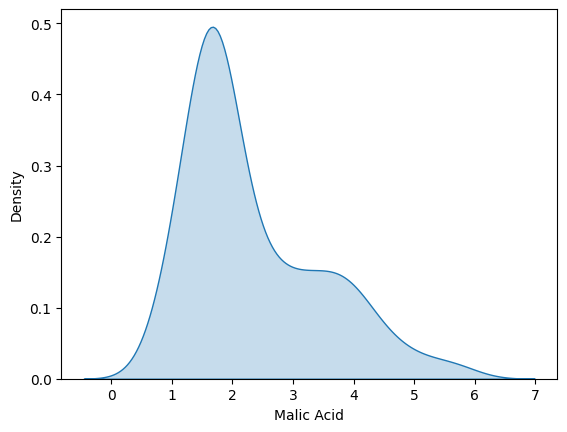

In [11]:
sns.kdeplot(df['Malic Acid'], fill=True)

<Axes: xlabel='Alcohol', ylabel='Malic Acid'>

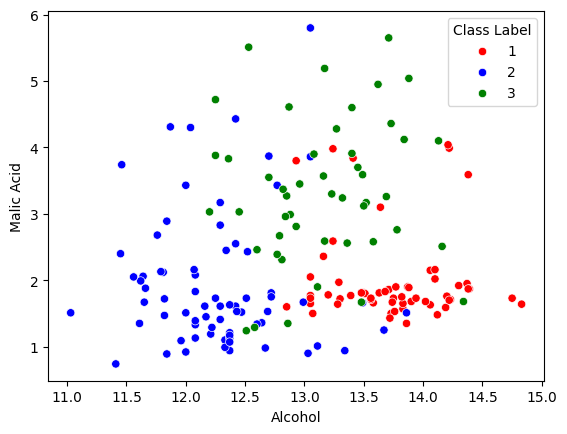

In [12]:
color_dict = {1:'red', 3:'green', 2:'blue'}
sns.scatterplot(x=df['Alcohol'], y=df['Malic Acid'], hue=df['Class Label'], palette=color_dict)

In [14]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    df.drop('Class Label', axis=1),
    df['Class Label'],
    test_size=0.3,
    random_state=0
)
X_train.shape, X_test.shape

((124, 2), (54, 2))

In [15]:
# MinMaxScaling Alcohol feature
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [16]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [20]:
np.round(X_train.describe(), 1)

,Alcohol,Malic Acid
count,124.0,124.0
mean,13.0,2.4
std,0.8,1.1
min,11.0,0.9
25%,12.4,1.6
50%,13.0,1.9
75%,13.6,3.2
max,14.8,5.6
